In [ ]:
import pandas as pd
import numpy as np


In [ ]:
import pandas as pd
import numpy as np

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print(matches.shape)
print(deliveries.shape)

(1095, 11)
(30730, 8)


In [ ]:
import pandas as pd
df = pd.read_csv("deliveries.csv")
df.head()

,inning,over,batting_team,bowling_team,batsman,bowler,batsman_runs,extras
0,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,0.0,1.0
1,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0.0,0.0
2,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0.0,1.0
3,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0.0,0.0
4,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0.0,0.0


In [ ]:
import pandas as pd
df = pd.read_csv("matches.csv")
df.head()

,team1,neutralvenue,venue,date,team2,season,city,winner,event,toss_winner,toss_decision
0,Royal Challengers Bangalore,NaN,M Chinnaswamy Stadium,18-04-2008,Kolkata Knight Riders,2007/08,Bangalore,Kolkata Knight Riders,Indian Premier League,Royal Challengers Bangalore,field
1,Kings XI Punjab,NaN,"Punjab Cricket Association Stadium, Mohali",19-04-2008,Chennai Super Kings,2007/08,Chandigarh,Chennai Super Kings,Indian Premier League,Chennai Super Kings,bat
2,Delhi Daredevils,NaN,Feroz Shah Kotla,19-04-2008,Rajasthan Royals,2007/08,Delhi,Delhi Daredevils,Indian Premier League,Rajasthan Royals,bat
3,Mumbai Indians,NaN,Wankhede Stadium,20-04-2008,Royal Challengers Bangalore,2007/08,Mumbai,Royal Challengers Bangalore,Indian Premier League,Mumbai Indians,bat
4,Kolkata Knight Riders,NaN,Eden Gardens,20-04-2008,Deccan Chargers,2007/08,Kolkata,Kolkata Knight Riders,Indian Premier League,Deccan Chargers,bat


In [ ]:
df.isnull().sum()

,0
team1,0
neutralvenue,1018
venue,0
date,0
team2,0
season,0
city,51
winner,19
event,0
toss_winner,0


In [ ]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)


In [ ]:
extra_cols = [
    'isWide','isNoBall','Byes','LegByes','Penalty',
    'Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)


In [ ]:
for col in ['dismissal_kind']:
    if col in deliveries.columns:
        deliveries[col].fillna("None", inplace=True)



In [ ]:
extra_cols = [
    'isWide','isNoBall','Byes','LegByes',
    'Penalty','Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)


In [ ]:
# Handle extras
extra_cols = [
    'isWide','isNoBall','Byes','LegByes',
    'Penalty','Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)

# Handle dismissal info
if 'dismissal_kind' in deliveries.columns:
    deliveries['dismissal_kind'].fillna("None", inplace=True)


In [ ]:
# Separate numeric and categorical columns
num_cols = deliveries.select_dtypes(include=['int64','float64']).columns
cat_cols = deliveries.select_dtypes(include=['object']).columns

# Fill missing values
deliveries[num_cols] = deliveries[num_cols].fillna(0)
deliveries[cat_cols] = deliveries[cat_cols].fillna("None")


In [ ]:
print("Deliveries missing values:\n", deliveries.isnull().sum())
print("\nMatches missing values:\n", matches.isnull().sum())


Deliveries missing values:
 inning          0
over            0
batting_team    0
bowling_team    0
batsman         0
bowler          0
batsman_runs    0
extras          0
dtype: int64

Matches missing values:
 team1               0
neutralvenue     1018
venue               0
date                0
team2               0
season              0
city               51
winner             19
event               0
toss_winner         0
toss_decision       0
dtype: int64


In [ ]:
# Numeric columns
num_cols = matches.select_dtypes(include=['int64','float64']).columns
matches[num_cols] = matches[num_cols].fillna(0)

# Categorical columns
cat_cols = matches.select_dtypes(include=['object']).columns
matches[cat_cols] = matches[cat_cols].fillna("Unknown")

# Date column (if exists)
if 'dates' in matches.columns:
    matches['dates'] = pd.to_datetime(matches['dates'], errors='coerce')


In [ ]:
deliveries.to_csv("deliveries_cleaned.csv", index=False)
matches.to_csv("matches_cleaned.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


EDA

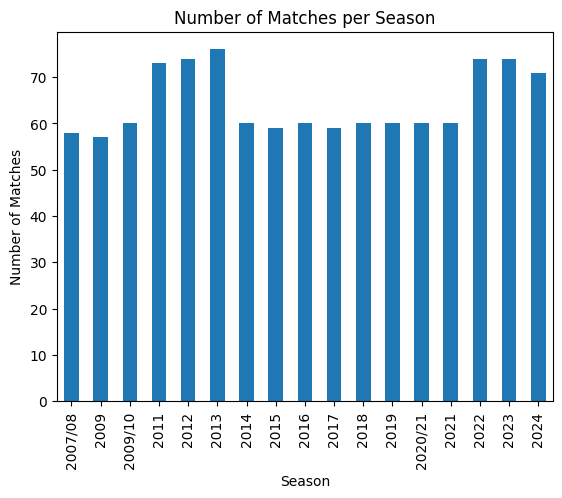

In [ ]:
import matplotlib.pyplot as plt

matches_per_season = matches['season'].value_counts().sort_index()

plt.figure()
matches_per_season.plot(kind='bar')
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()


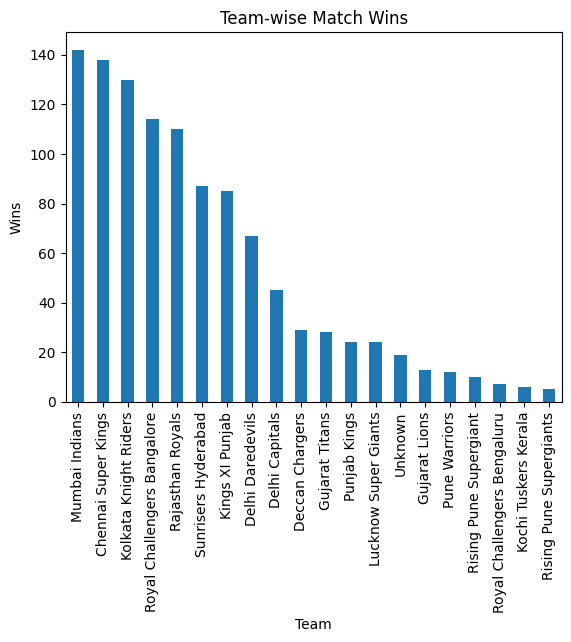

In [ ]:
team_wins = matches['winner'].value_counts()

plt.figure()
team_wins.plot(kind='bar')
plt.title("Team-wise Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()


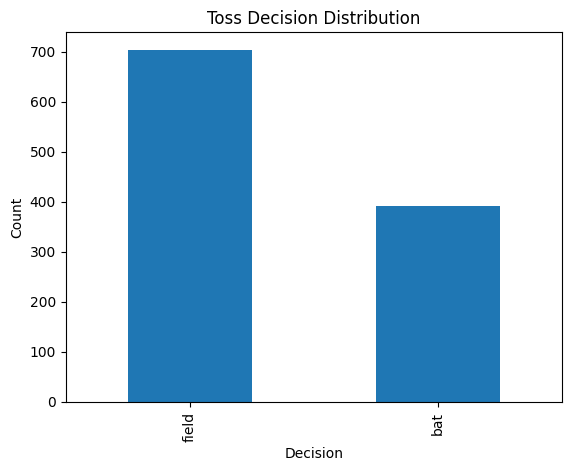

In [ ]:
plt.figure()
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title("Toss Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()


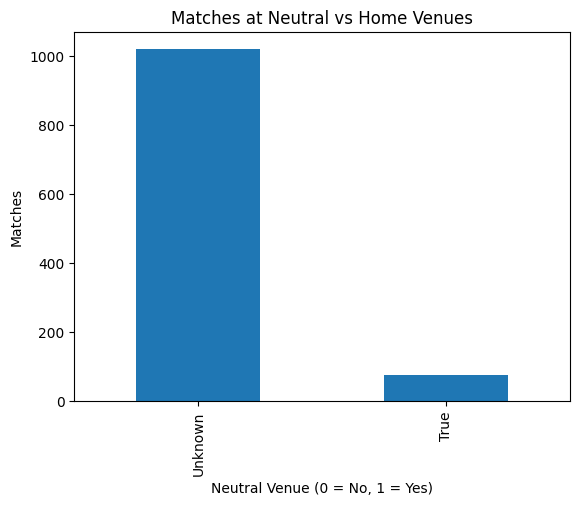

In [ ]:
plt.figure()
matches['neutralvenue'].value_counts().plot(kind='bar')
plt.title("Matches at Neutral vs Home Venues")
plt.xlabel("Neutral Venue (0 = No, 1 = Yes)")
plt.ylabel("Matches")
plt.show()


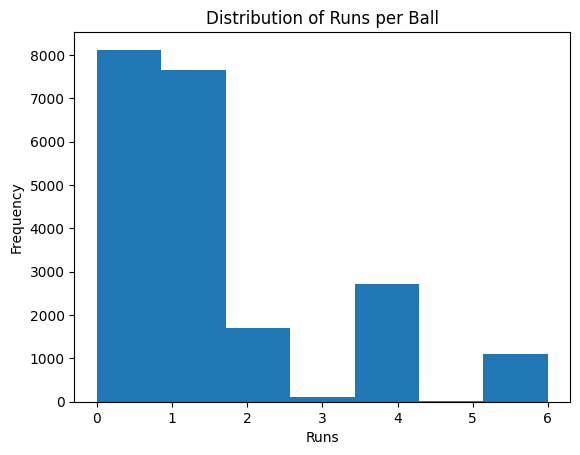

In [ ]:
plt.figure()
plt.hist(deliveries['batsman_runs'], bins=7)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


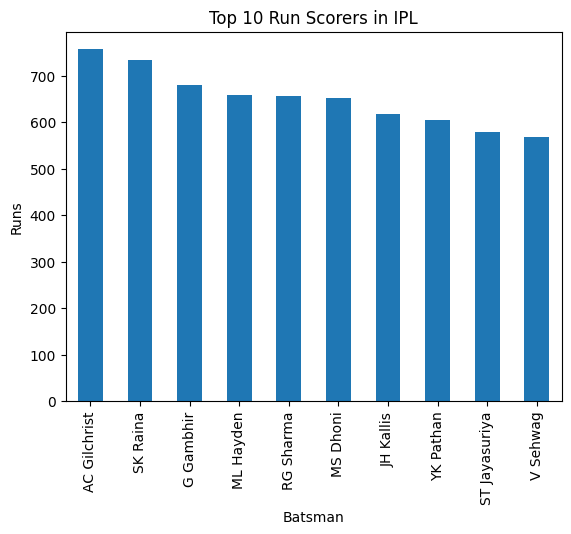

In [ ]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_batsmen.plot(kind='bar')
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()


STEP 1: MATCH-LEVEL FEATURE ENGINEERING

In [ ]:
player_runs = deliveries.groupby('batsman')['batsman_runs'].sum().reset_index()
player_runs.columns = ['batsman', 'total_runs']


In [ ]:
balls_faced = deliveries.groupby('batsman')['batsman_runs'].count().reset_index()
balls_faced.columns = ['batsman', 'balls_faced']


In [ ]:
player_runs['strike_rate'] = (player_runs['total_runs'] / balls_faced['balls_faced']) * 100


In [ ]:
boundaries = deliveries[deliveries['batsman_runs'].isin([4,6])]
boundary_count = boundaries.groupby('batsman')['batsman_runs'].count().reset_index()
boundary_count.columns = ['batsman', 'boundary_count']


In [ ]:
player_features = player_runs.merge(balls_faced, on='batsman')
player_features = player_features.merge(boundary_count, on='batsman', how='left')
player_features.fillna(0, inplace=True)


In [33]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [34]:
!apt-get install git -qq


In [35]:
!git config --global user.name "Pooja2600"
!git config --global user.email "spoo.aiml2024@rmd.ac.in"


In [38]:
# Clone repo (only first time)
!git clone https://github.com/mentor-pranaya/Cricket-Player-Performance-Prediction.git


Cloning into 'Cricket-Player-Performance-Prediction'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 69 (delta 4), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 2.33 MiB | 10.73 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [39]:
# Go inside repo
%cd /content/Cricket-Player-Performance-Prediction


/content/Cricket-Player-Performance-Prediction


In [40]:
# Switch to Pooja branch
!git checkout Pooja


Branch 'Pooja' set up to track remote branch 'Pooja' from 'origin'.
Switched to a new branch 'Pooja'


In [42]:
!cp /content/*.py .


cp: cannot stat '/content/*.py': No such file or directory


In [43]:
!git add .
!git commit -m "Updated ML code and analysis notebooks"
!git push origin Pooja


On branch Pooja
Your branch is up to date with 'origin/Pooja'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [44]:
!git status


On branch Pooja
Your branch is up to date with 'origin/Pooja'.

nothing to commit, working tree clean


In [45]:
!cp /content/Untitled0.ipynb /content/Cricket-Player-Performance-Prediction/


cp: cannot stat '/content/Untitled0.ipynb': No such file or directory


In [46]:
!ls /content


Cricket-Player-Performance-Prediction  drive		    sample_data
deliveries_cleaned.csv		       matches_cleaned.csv
deliveries.csv			       matches.csv


In [48]:
!cp /content/Cricketplayeranalysis.ipynb/content/Cricket-Player-Performance-Prediction/


cp: missing destination file operand after '/content/Cricketplayeranalysis.ipynb/content/Cricket-Player-Performance-Prediction/'
Try 'cp --help' for more information.


In [52]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
